# PyTorch Computer vision

## 1.Computer vision libraries

* torchvision - base domain library
* torchvision.datasets
* torchvision.models - get pretrained models
* torchvision.transformers
* torch.utils.data.Dataset
* torch.utils.data.DataLoader



In [1]:
import torch
from torch import nn
#Torch Vison
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


##1.Getting a Dataset
>  CIFAR10


In [2]:
#Setup training data
train_data = datasets.CIFAR10(
    root = 'data',
    train =True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data =  datasets.CIFAR10(
    root = 'data',
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 170M/170M [00:15<00:00, 11.1MB/s]


In [3]:
len(train_data), len(test_data)

(50000, 10000)

In [4]:
image, label = train_data[0]
image, label

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [5]:
class_names = train_data.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [7]:
train_data.targets

[6,
 9,
 9,
 4,
 1,
 1,
 2,
 7,
 8,
 3,
 4,
 7,
 7,
 2,
 9,
 9,
 9,
 3,
 2,
 6,
 4,
 3,
 6,
 6,
 2,
 6,
 3,
 5,
 4,
 0,
 0,
 9,
 1,
 3,
 4,
 0,
 3,
 7,
 3,
 3,
 5,
 2,
 2,
 7,
 1,
 1,
 1,
 2,
 2,
 0,
 9,
 5,
 7,
 9,
 2,
 2,
 5,
 2,
 4,
 3,
 1,
 1,
 8,
 2,
 1,
 1,
 4,
 9,
 7,
 8,
 5,
 9,
 6,
 7,
 3,
 1,
 9,
 0,
 3,
 1,
 3,
 5,
 4,
 5,
 7,
 7,
 4,
 7,
 9,
 4,
 2,
 3,
 8,
 0,
 1,
 6,
 1,
 1,
 4,
 1,
 8,
 3,
 9,
 6,
 6,
 1,
 8,
 5,
 2,
 9,
 9,
 8,
 1,
 7,
 7,
 0,
 0,
 6,
 9,
 1,
 2,
 2,
 9,
 2,
 6,
 6,
 1,
 9,
 5,
 0,
 4,
 7,
 6,
 7,
 1,
 8,
 1,
 1,
 2,
 8,
 1,
 3,
 3,
 6,
 2,
 4,
 9,
 9,
 5,
 4,
 3,
 6,
 7,
 4,
 6,
 8,
 5,
 5,
 4,
 3,
 1,
 8,
 4,
 7,
 6,
 0,
 9,
 5,
 1,
 3,
 8,
 2,
 7,
 5,
 3,
 4,
 1,
 5,
 7,
 0,
 4,
 7,
 5,
 5,
 1,
 0,
 9,
 6,
 9,
 0,
 8,
 7,
 8,
 8,
 2,
 5,
 2,
 3,
 5,
 0,
 6,
 1,
 9,
 3,
 6,
 9,
 1,
 3,
 9,
 6,
 6,
 7,
 1,
 0,
 9,
 5,
 8,
 5,
 2,
 9,
 0,
 8,
 8,
 0,
 6,
 9,
 1,
 1,
 6,
 3,
 7,
 6,
 6,
 0,
 6,
 6,
 1,
 7,
 1,
 5,
 8,
 3,
 6,
 6,
 8,
 6,
 8,
 4,
 6,
 6,


In [8]:
print(f'Image shape={image.shape}, Labels ={label}')
class_names

Image shape=torch.Size([3, 32, 32]), Labels =6


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

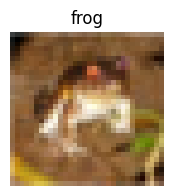

In [9]:
#Visualize
import matplotlib.pyplot as plt
image, label = train_data[0]
image = image.permute(1, 2, 0)
plt.figure(figsize=(2,2))
plt.imshow(image)  # default colormap for RGB
plt.title(class_names[label])
plt.axis('off')
plt.show()

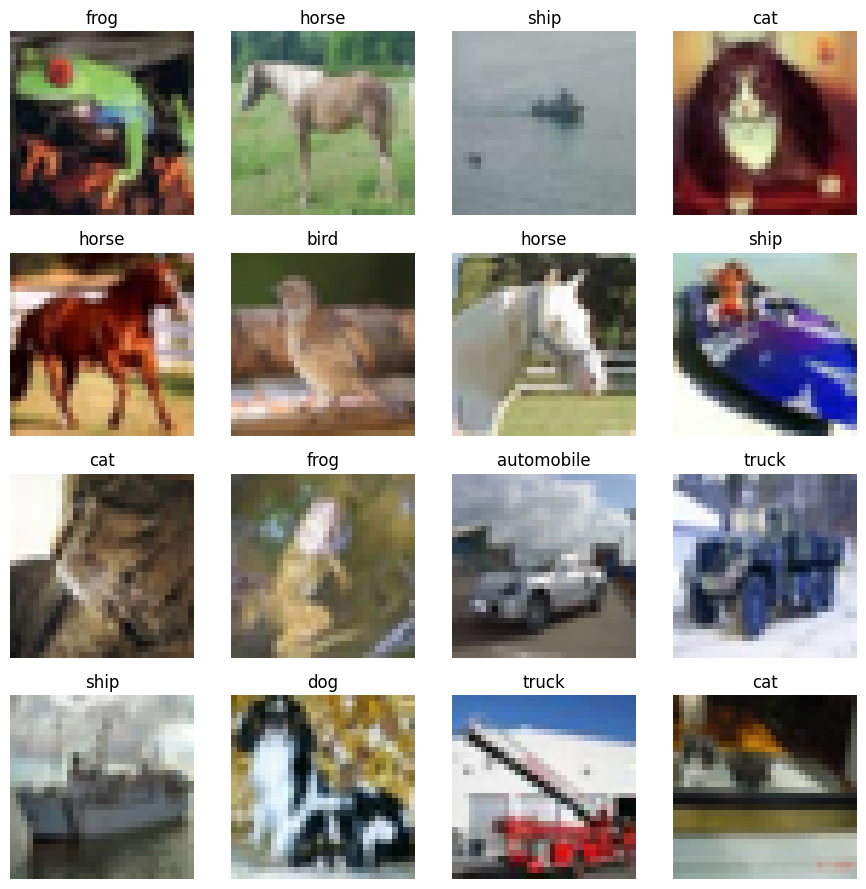

In [10]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows * cols + 1):
    rand = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[rand]

    img = img.permute(1, 2, 0)  # [C, H, W] → [H, W, C] for matplotlib

    ax = fig.add_subplot(rows, cols, i)
    ax.imshow(img)
    ax.set_title(class_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

# 2.Prepare Data Loader

In [11]:
train_data,test_data

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [13]:
from torch.utils.data import DataLoader

#Set up batch size hyperparameter
batch = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=batch,
                            shuffle=True)

test_dataloader = DataLoader(dataset= test_data,
                             batch_size=batch,
                             shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e2f713bb610>,
 <torch.utils.data.dataloader.DataLoader at 0x7e2f714e0dd0>)

In [14]:
#Check what is creaked
print(f'DataLoaders: {train_dataloader, test_dataloader}')
print(f'Lenght of train: {len(train_dataloader)} batches of {batch}')
print(f'Lenght of train: {len(test_dataloader)} batches of {batch}')

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e2f713bb610>, <torch.utils.data.dataloader.DataLoader object at 0x7e2f714e0dd0>)
Lenght of train: 1563 batches of 32
Lenght of train: 313 batches of 32


In [15]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 32, 32]), torch.Size([32]))

Image size: torch.Size([32, 32, 3])
Label: 8, Label size: torch.Size([])


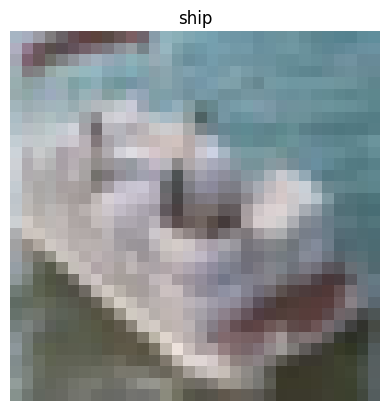

In [16]:
#Visualizing a single peice of a dataloader
torch.manual_seed(42)
random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img=train_features_batch[random_idx]
label=train_labels_batch[random_idx]
img=img.permute(1,2,0)
plt.imshow(img)
plt.title(class_names[label.item()])
plt.axis('off')
print(f'Image size: {img.shape}')
print(f'Label: {label}, Label size: {label.shape}')


#3.Model building

beginning from model 0

In [17]:
flatten_model = nn.Flatten()

x=train_features_batch[0]

output = flatten_model(x)
print(output.shape)

torch.Size([3, 1024])


In [18]:
import torch
from torch import nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False, use_se=True):
        super().__init__()
        stride = 2 if downsample else 1

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.PReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.se = SEBlock(out_channels) if use_se else nn.Identity()
        self.downsample = (
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            if in_channels != out_channels or downsample else nn.Identity()
        )
        self.activation = nn.PReLU()

    def forward(self, x):
        identity = self.downsample(x)
        out = self.block(x)
        out = self.se(out)
        out += identity
        return self.activation(out)

class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, stride=1, bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU()
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(64, 128, downsample=True),
            ResidualBlock(128, 128)
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(128, 256, downsample=True),
            ResidualBlock(256, 256)
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(256, 512, downsample=True),
            ResidualBlock(512, 512)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.PReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


In [19]:
torch.manual_seed(42)

model_0 = CIFAR10Model()
model_0.to(device)
model_0


CIFAR10Model(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=1)
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (se): SEBlock(
        (pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=128, out_features=8, bias=True)
          (1): ReLU()
          (2): Linear(in_features=8, out_features=128, bias=True)
         

In [20]:
next(model_0.parameters()).device


device(type='cuda', index=0)

In [21]:
dummy_x = torch.rand([1, 3, 32, 32]).to(device)  # Correct shape for CIFAR-10
model_0(dummy_x)


tensor([[-0.1247,  0.0110, -0.0782, -0.5030, -0.1378,  0.0227,  0.0480,  0.1036,
          0.0200,  0.1235]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [22]:
model_0.state_dict()

OrderedDict([('stem.0.weight',
              tensor([[[[ 0.1471,  0.1597, -0.0451],
                        [ 0.1768, -0.0422,  0.0388],
                        [-0.0937,  0.1130,  0.1697]],
              
                       [[-0.1412,  0.1673,  0.0360],
                        [ 0.1422,  0.0261,  0.0928],
                        [-0.0272,  0.1484,  0.0284]],
              
                       [[-0.0898,  0.0491, -0.0887],
                        [-0.0226, -0.0782,  0.1277],
                        [-0.1519, -0.0887, -0.0543]]],
              
              
                      [[[-0.1157,  0.0182, -0.1901],
                        [ 0.1738, -0.1635,  0.1486],
                        [ 0.0320, -0.0625,  0.1189]],
              
                       [[ 0.0300,  0.1555,  0.0210],
                        [-0.0607,  0.0517, -0.0522],
                        [ 0.0810,  0.1718,  0.1112]],
              
                       [[-0.0841,  0.1111,  0.0344],
                        [

In [23]:
import requests
from pathlib import Path
#Download helper functions
if Path('helper_functions.py').is_file():
  print('File already exists, skipping download')
else:
  print('Downloading file')
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/af6548e52663c8395fe2777bd0fbfd6ac85fd6f8/helper_functions.py")
  with open('helper_functions.py','wb') as f:
    f.write(request.content)

In [26]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model_0.parameters(), lr=1e-3, weight_decay=1e-4)


In [27]:
#Creating a function to time our experiments
from timeit import default_timer as timer
def print_train_time(start:float,
                     end: float,
                     device: torch.device = None):
  total_time = end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [28]:
start_time =timer()
end_time=timer()
print_train_time(start=start_time, end=end_time, device= 'cpu')

Train time on cpu: 0.000 seconds


3.69550000414165e-05

In [29]:
from tqdm.auto import tqdm


torch.manual_seed(42)
epochs = 10
for epoch in tqdm(range(epochs)):
  if epoch % 10 == 0:
    print(f'Epoch: {epoch}\n-----------')
  train_loss = 0
  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)  # <-- move to device
    model_0.train()
    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 2500 == 0:
      print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')

  train_loss /= len(train_dataloader)

    # Evaluation
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_dataloader:
      X, y = X.to(device), y.to(device)
      test_pred = model_0(X)
      test_loss += loss_fn(test_pred, y).item()
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))



    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    print(f'Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}')


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
-----------
Looked at 0/50000 samples
Train loss: 1.38732 | Test loss: 1.00022 | Test acc: 63.80
Looked at 0/50000 samples
Train loss: 0.85481 | Test loss: 0.73667 | Test acc: 75.10
Looked at 0/50000 samples
Train loss: 0.60707 | Test loss: 0.65539 | Test acc: 78.04
Looked at 0/50000 samples
Train loss: 0.43128 | Test loss: 0.54677 | Test acc: 82.21
Looked at 0/50000 samples
Train loss: 0.29729 | Test loss: 0.65450 | Test acc: 79.42
Looked at 0/50000 samples
Train loss: 0.19587 | Test loss: 0.70014 | Test acc: 81.73
Looked at 0/50000 samples
Train loss: 0.13834 | Test loss: 0.69068 | Test acc: 82.16
Looked at 0/50000 samples
Train loss: 0.11310 | Test loss: 0.84808 | Test acc: 80.12
Looked at 0/50000 samples
Train loss: 0.09041 | Test loss: 0.93318 | Test acc: 80.04
Looked at 0/50000 samples
Train loss: 0.07900 | Test loss: 0.83436 | Test acc: 82.25


#4. Make predictions and get results

In [30]:
from tqdm.auto import tqdm
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for x, y in tqdm(data_loader):
            x, y = x.to(device), y.to(device)  # <-- move to device
            y_pred = model(x)
            loss += loss_fn(y_pred, y).item()
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
    'Model Name': model.__class__.__name__,
    'Model Loss': loss,
    'Model Accuracy': acc
}



model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'Model Name': 'CIFAR10Model',
 'Model Loss': 0.8343585096180629,
 'Model Accuracy': 82.24840255591054}

In [31]:
!pip install Pillow
from PIL import ImageOps

In [33]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_0.to(device)

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    model_0.eval()
    with torch.no_grad():
        output = model_0(image_tensor)
        _, predicted_class = torch.max(output, 1)
    return predicted_class.item(), image_tensor.squeeze()


image_path = '/content/cat.png'
predicted_class, image_tensor = predict_image(image_path)
print(f'Predicted Class: {predicted_class}')
print(f'Class Name: {class_names[predicted_class]}')


Predicted Class: 3
Class Name: cat
